# 07 - Neural Nets with TensorFlow

In this notebook, we explore how to use pre-trained neural networks with TensorFlow/Keras for image classification. We use the **Xception** architecture pre-trained on ImageNet and apply transfer learning to classify clothing items into 10 categories (dress, hat, longsleeve, outwear, pants, shirt, shoes, shorts, skirt, t-shirt).

**Topics covered:**
- Loading and using a pre-trained model (Xception)
- Transfer learning with frozen base layers
- Hyperparameter tuning (learning rate, layer size, dropout)
- Data augmentation
- Model checkpointing
- Evaluating and making predictions with the final model


## Loading a Pre-trained Model

We start by loading the Xception model pre-trained on ImageNet. Xception is a deep convolutional neural network architecture that achieves excellent performance on image classification tasks. We first demonstrate how to use it for inference on a single image.


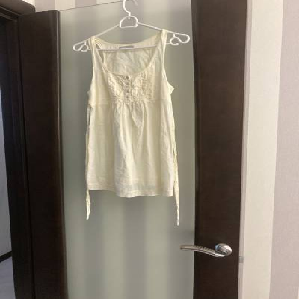

In [1]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img
from tensorflow import keras

image_path = './data/train/dress/0a69db60-c052-4b9a-a90d-e53120d091d5.jpg'
img = load_img(image_path, target_size=(299, 299))
img

In [2]:
img_np = np.array(img)
img_np.shape

(299, 299, 3)

In [3]:
from tensorflow.keras.applications.xception import Xception, preprocess_input, decode_predictions

model = Xception(
    weights="imagenet",
    input_shape=(299, 299, 3),
    name="xception",
)

In [4]:
X = np.array([img])
X.shape

(1, 299, 299, 3)

In [5]:
pred = model.predict(preprocess_input(X))
decode_predictions(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step


[[('n04550184', 'wardrobe', np.float32(0.39527908)),
  ('n04209239', 'shower_curtain', np.float32(0.16426855)),
  ('n03742115', 'medicine_chest', np.float32(0.060920876)),
  ('n04553703', 'washbasin', np.float32(0.028017603)),
  ('n02808440', 'bathtub', np.float32(0.017973768))]]

## Data Preparation

We use `ImageDataGenerator` to load images from directories and preprocess them. The dataset is split into training (3068 images) and validation (341 images) sets across 10 classes. Images are resized to 150x150 pixels and batched in groups of 32.


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
validation_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory(
    './data/train', 
    target_size=(150, 150), 
    batch_size=32)

validation_ds = validation_gen.flow_from_directory(
    './data/validation', 
    target_size=(150, 150), 
    batch_size=32,
    shuffle=False)

X, y = next(train_ds)

print(X.shape)
print(y.shape)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.
(32, 150, 150, 3)
(32, 10)


In [7]:
print(train_ds.class_indices)
print(y[:5])

{'dress': 0, 'hat': 1, 'longsleeve': 2, 'outwear': 3, 'pants': 4, 'shirt': 5, 'shoes': 6, 'shorts': 7, 'skirt': 8, 't-shirt': 9}
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


## Transfer Learning: Freezing the Base Model

For transfer learning, we load Xception without its top classification layer (`include_top=False`) and freeze all its pre-trained weights (`trainable=False`). This means the convolutional base acts as a fixed feature extractor — only the new layers we add on top will be trained.


In [8]:
base_model = Xception(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

base_model.trainable = False

## Building the Model

We create a model by adding a `GlobalAveragePooling2D` layer followed by a `Dense` output layer with 10 units (one per class). The model uses:
- **Adam** optimizer
- **Categorical Crossentropy** loss (from logits)
- **Accuracy** as the evaluation metric


In [16]:
def create_model(learning_rate=0.01):

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    pooling = keras.layers.GlobalAveragePooling2D()
    vectors = pooling(base)
    outputs = keras.layers.Dense(10)(vectors)
    model = keras.Model(inputs=inputs, outputs=outputs)

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer, 
        loss=loss, 
        metrics=['accuracy'])

    return model

## Training the Model

We train the model for 10 epochs using the default learning rate of 0.001. The training and validation accuracy are tracked in the `history` object.


In [ ]:
model = create_model()
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 305ms/step - accuracy: 0.6757 - loss: 1.1585 - val_accuracy: 0.7771 - val_loss: 0.8446
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 257ms/step - accuracy: 0.8338 - loss: 0.5109 - val_accuracy: 0.8035 - val_loss: 0.7922
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 265ms/step - accuracy: 0.8745 - loss: 0.3558 - val_accuracy: 0.7918 - val_loss: 0.7603
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 289ms/step - accuracy: 0.9166 - loss: 0.2442 - val_accuracy: 0.8270 - val_loss: 0.8227
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 255ms/step - accuracy: 0.9472 - loss: 0.1501 - val_accuracy: 0.8211 - val_loss: 0.8357
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 256ms/step - accuracy: 0.9668 - loss: 0.0997 - val_accuracy: 0.8182 - val_loss: 0.8689
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 293ms/step - accuracy: 0.9674 - loss: 0.0953 - val_accuracy: 0.8152 - val_loss: 0.8559
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 341ms/step - accuracy: 0.9814 - loss: 0.0549 - val_accu

## Evaluating the Training

We plot the training and validation accuracy over epochs to visualize the model's learning progress and check for overfitting.


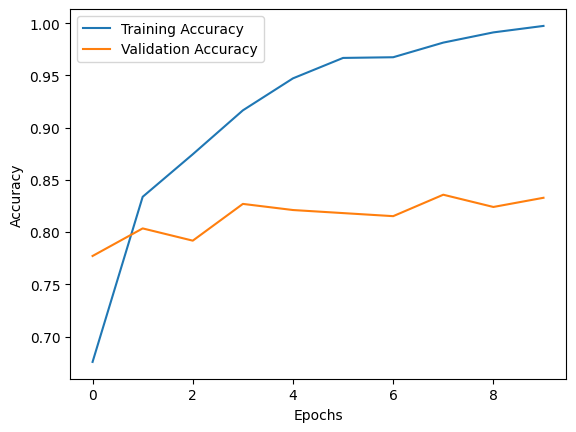

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

## Hyperparameter Tuning: Learning Rate

The learning rate is one of the most important hyperparameters. Too high and training may diverge; too low and training will be slow. We try 4 different learning rates: 0.0001, 0.001, 0.01, and 0.1.


In [17]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]

scores = {}

for lr in learning_rates:
    print(lr)
    model = create_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=validation_ds)
    scores[lr] = history.history

0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 264ms/step - accuracy: 0.3282 - loss: 1.9901 - val_accuracy: 0.4457 - val_loss: 1.6983
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 263ms/step - accuracy: 0.5515 - loss: 1.4190 - val_accuracy: 0.5894 - val_loss: 1.3203
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 272ms/step - accuracy: 0.6379 - loss: 1.1649 - val_accuracy: 0.6246 - val_loss: 1.1238
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 262ms/step - accuracy: 0.6763 - loss: 1.0213 - val_accuracy: 0.6716 - val_loss: 1.0076
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 247ms/step - accuracy: 0.7034 - loss: 0.9232 - val_accuracy: 0.6950 - val_loss: 0.9262
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 303ms/step - accuracy: 0.7275 - loss: 0.8540 - val_accuracy: 0.7067 - val_loss: 0.8667
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 283ms/step - accuracy: 0.7392 - loss: 0.8009 - val_accuracy: 0.7273 - val_loss: 0.8205
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 246ms/step - accuracy: 0.7542 - loss: 0.7566 - v

In [18]:
for lr, history in scores.items():
    print(lr, history)

0.0001 {'accuracy': [0.32822686433792114, 0.5514993667602539, 0.6378748416900635, 0.6763363480567932, 0.7033898234367371, 0.7275097966194153, 0.7392438054084778, 0.7542372941970825, 0.7656453847885132, 0.7764015793800354], 'loss': [1.9900927543640137, 1.4190032482147217, 1.1648766994476318, 1.0212700366973877, 0.9231550097465515, 0.8539963364601135, 0.8008798956871033, 0.7565837502479553, 0.7206587791442871, 0.6881443858146667], 'val_accuracy': [0.4457477927207947, 0.589442789554596, 0.6246334314346313, 0.6715542674064636, 0.6950146555900574, 0.7067448496818542, 0.7272727489471436, 0.7565982341766357, 0.7683284282684326, 0.7683284282684326], 'val_loss': [1.6982958316802979, 1.3202943801879883, 1.1237690448760986, 1.0075620412826538, 0.9261840581893921, 0.8667199015617371, 0.8204683065414429, 0.7826680541038513, 0.7530258893966675, 0.733687162399292]}
0.001 {'accuracy': [0.6248370409011841, 0.7803128957748413, 0.8275749683380127, 0.8582138419151306, 0.883637547492981, 0.9015645384788513

## Comparing Learning Rates

We plot the training accuracy curves for each learning rate to visually compare their performance.


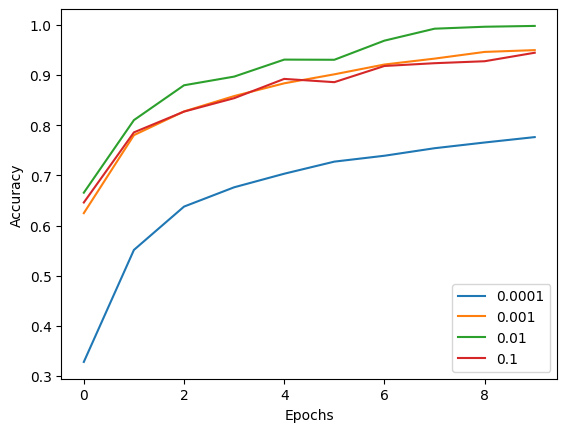

In [22]:
for lr, history in scores.items():
    plt.plot(history['accuracy'], label=lr)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

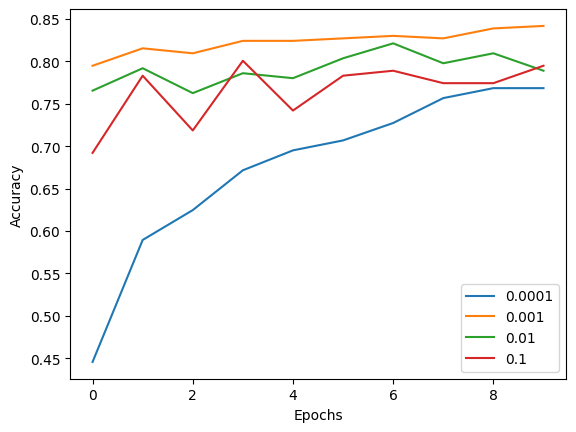

In [23]:
for lr, history in scores.items():
    plt.plot(history['val_accuracy'], label=lr)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Model Checkpointing

To avoid losing the best model, we use `ModelCheckpoint` to save model weights after each epoch. By setting `save_best_only=True` and monitoring validation accuracy, only the best-performing model is kept.


In [31]:
model.save_weights('model_v1.weights.h5')

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath='xception_v1_{epoch:02d}_val_acc_{val_accuracy:.3f}.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

model = create_model(learning_rate=0.001)
history = model.fit(
    train_ds, 
    epochs=10, 
    validation_data=validation_ds,
    callbacks=[checkpoint]
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.6385 - loss: 1.0861

96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 301ms/step - accuracy: 0.6385 - loss: 1.0861 - val_accuracy: 0.7742 - val_loss: 0.6906
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.7924 - loss: 0.6296

96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 271ms/step - accuracy: 0.7924 - loss: 0.6296 - val_accuracy: 0.8240 - val_loss: 0.6065
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 254ms/step - accuracy: 0.8276 - loss: 0.5086 - val_accuracy: 0.8123 - val_loss: 0.5682
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 274ms/step - accuracy: 0.8621 - loss: 0.4271 - val_accuracy: 0.8152 - val_loss: 0.5444
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.8872 - loss: 0.3718

96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 261ms/step - accuracy: 0.8872 - loss: 0.3718 - val_accuracy: 0.8270 - val_loss: 0.5430
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9025 - loss: 0.3232

96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 260ms/step - accuracy: 0.9025 - loss: 0.3232 - val_accuracy: 0.8328 - val_loss: 0.5301
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9211 - loss: 0.2870

96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 265ms/step - accuracy: 0.9211 - loss: 0.2870 - val_accuracy: 0.8387 - val_loss: 0.5214
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 248ms/step - accuracy: 0.9302 - loss: 0.2586 - val_accuracy: 0.8152 - val_loss: 0.5307
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 258ms/step - accuracy: 0.9420 - loss: 0.2296 - val_accuracy: 0.8358 - val_loss: 0.5253
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 255ms/step - accuracy: 0.9498 - loss: 0.2076 - val_accuracy: 0.8240 - val_loss: 0.5492


## Adding an Inner Dense Layer

To increase model capacity, we add an intermediate `Dense` layer with ReLU activation between the pooling layer and the output layer. This gives the model more flexibility to learn complex patterns.


In [34]:
def create_model_v2(learning_rate=0.001, inner_size=100):

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    pooling = keras.layers.GlobalAveragePooling2D()
    vectors = pooling(base)
    inner = keras.layers.Dense(inner_size, activation='relu')(vectors)
    outputs = keras.layers.Dense(10)(inner)
    model = keras.Model(inputs=inputs, outputs=outputs)

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer, 
        loss=loss, 
        metrics=['accuracy'])

    return model

## Tuning the Inner Layer Size

We experiment with different sizes for the inner dense layer: 10, 100, and 1000 units.


In [35]:
scores = {}

for size in [10, 100, 1000]:
    print(size)
    model = create_model_v2(inner_size=size)
    history = model.fit(train_ds, epochs=10, validation_data=validation_ds)
    scores[size] = history.history

10
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 259ms/step - accuracy: 0.5209 - loss: 1.4125 - val_accuracy: 0.6628 - val_loss: 1.0233
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 260ms/step - accuracy: 0.7073 - loss: 0.8524 - val_accuracy: 0.7449 - val_loss: 0.8272
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 286ms/step - accuracy: 0.7832 - loss: 0.6447 - val_accuracy: 0.7859 - val_loss: 0.6589
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 258ms/step - accuracy: 0.8328 - loss: 0.5241 - val_accuracy: 0.7977 - val_loss: 0.6177
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 252ms/step - accuracy: 0.8576 - loss: 0.4417 - val_accuracy: 0.8006 - val_loss: 0.5990
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 279ms/step - accuracy: 0.8872 - loss: 0.3762 - val_accuracy: 0.8123 - val_loss: 0.5911
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 251ms/step - accuracy: 0.9058 - loss: 0.3215 - val_accuracy: 0.8123 - val_loss: 0.5827
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 245ms/step - accuracy: 0.9273 - loss: 0.2733 - val_a

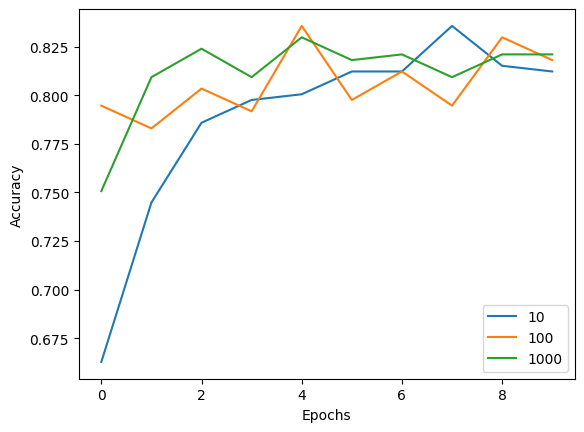

In [37]:
for size, history in scores.items():
    plt.plot(history['val_accuracy'], label=size)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Adding Dropout Regularization

To combat overfitting, we add a `Dropout` layer after the inner dense layer. Dropout randomly sets a fraction of input units to 0 during training, forcing the network to learn more robust features.


In [38]:
def create_model_v3(learning_rate=0.001, inner_size=100, drop_rate=0.2):

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    pooling = keras.layers.GlobalAveragePooling2D()
    vectors = pooling(base)
    inner = keras.layers.Dense(inner_size, activation='relu')(vectors)
    dropout = keras.layers.Dropout(drop_rate)(inner)
    outputs = keras.layers.Dense(10)(dropout)
    model = keras.Model(inputs=inputs, outputs=outputs)

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer, 
        loss=loss, 
        metrics=['accuracy'])

    return model

## Tuning the Dropout Rate

We test different dropout rates: 0.0 (no dropout), 0.2, 0.5, and 0.8. Training runs for 30 epochs for each rate to observe the effect on validation accuracy.


In [40]:
scores = {}

for rate in [0.0, 0.2, 0.5, 0.8]:
    print(rate)
    model = create_model_v3(drop_rate=rate)
    history = model.fit(train_ds, epochs=30, validation_data=validation_ds)
    scores[rate] = history.history

0.0
Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 280ms/step - accuracy: 0.6610 - loss: 1.0035 - val_accuracy: 0.7977 - val_loss: 0.6507
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 264ms/step - accuracy: 0.8136 - loss: 0.5297 - val_accuracy: 0.8152 - val_loss: 0.5795
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 256ms/step - accuracy: 0.8820 - loss: 0.3624 - val_accuracy: 0.8211 - val_loss: 0.5338
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 293ms/step - accuracy: 0.9231 - loss: 0.2615 - val_accuracy: 0.8123 - val_loss: 0.5744
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 264ms/step - accuracy: 0.9377 - loss: 0.2018 - val_accuracy: 0.8240 - val_loss: 0.5693
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 248ms/step - accuracy: 0.9697 - loss: 0.1283 - val_accuracy: 0.8065 - val_loss: 0.5678
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 264ms/step - accuracy: 0.9853 - loss: 0.0908 - val_accuracy: 0.8094 - val_loss: 0.5822
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 24s 254ms/step - accuracy: 0.9932 - loss: 0.0653 - val_

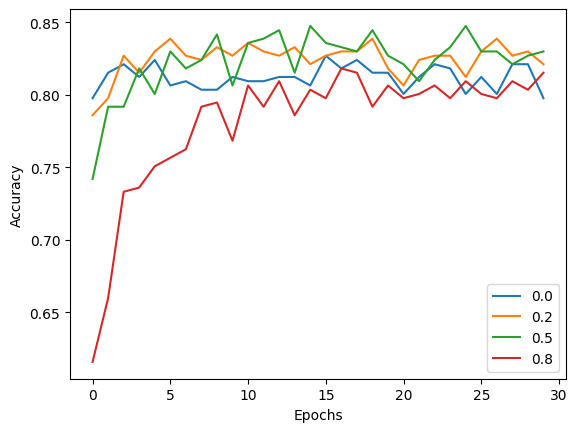

In [41]:
for drop_rate, history in scores.items():
    plt.plot(history['val_accuracy'], label=drop_rate)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Data Augmentation and Larger Input Size

We enhance the training data with augmentation (shear, zoom, horizontal flip) to improve generalization. We also increase the input image size from 150x150 to 299x299 — the native resolution of Xception — to leverage the full power of the pre-trained model.


In [52]:
image_size = (299, 299)
batch_size = 32


train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10.0,
    zoom_range=0.1,
    horizontal_flip=True,  
)

train_ds = train_gen.flow_from_directory(
    './data/train',
    seed=1,
    target_size=image_size,
    batch_size=batch_size,
)

validation_ds = validation_gen.flow_from_directory(
    './data/validation', 
    target_size=image_size, 
    batch_size=batch_size,
    shuffle=False)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


## Final Model (v4)

Our final model combines all the improvements:
- Larger input size (299x299)
- Inner dense layer with 100 units
- Dropout with 0.2 rate
- Data augmentation during training


In [53]:
base_model = Xception(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

base_model.trainable = False

def create_model_v4(learning_rate=0.001, inner_size=100, drop_rate=0.2):

    inputs = keras.Input(shape=(299, 299, 3))
    base = base_model(inputs, training=False)
    pooling = keras.layers.GlobalAveragePooling2D()
    vectors = pooling(base)
    inner = keras.layers.Dense(inner_size, activation='relu')(vectors)
    dropout = keras.layers.Dropout(drop_rate)(inner)
    outputs = keras.layers.Dense(10)(dropout)
    model = keras.Model(inputs=inputs, outputs=outputs)

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer, 
        loss=loss, 
        metrics=['accuracy'])

    return model

## Training the Final Model

We train the final model for 30 epochs with checkpointing enabled. The best checkpoint will be saved automatically based on validation accuracy.


In [55]:
learning_rate = 0.001
size = 100
drop_rate = 0.2

model.save_weights('model_v4.weights.h5')

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath='xception_v4_{epoch:02d}_val_acc_{val_accuracy:.3f}.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

model = create_model_v4(learning_rate=learning_rate,
                        inner_size=size,
                        drop_rate=drop_rate)

history = model.fit(
    train_ds,
    epochs=30,
    validation_data=validation_ds,
    callbacks=[checkpoint]
)

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7317 - loss: 0.8349

96/96 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.7317 - loss: 0.8349 - val_accuracy: 0.8475 - val_loss: 0.4483
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.8387 - loss: 0.4659 - val_accuracy: 0.8387 - val_loss: 0.4473
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.8634 - loss: 0.3963 - val_accuracy: 0.8446 - val_loss: 0.4189
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8830 - loss: 0.3363

96/96 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.8830 - loss: 0.3363 - val_accuracy: 0.8563 - val_loss: 0.3836
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8980 - loss: 0.2997

96/96 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.8980 - loss: 0.2997 - val_accuracy: 0.8622 - val_loss: 0.3544
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9120 - loss: 0.2626

96/96 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.9120 - loss: 0.2626 - val_accuracy: 0.8680 - val_loss: 0.3754
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9081 - loss: 0.2571

96/96 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.9081 - loss: 0.2571 - val_accuracy: 0.8739 - val_loss: 0.3685
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.9247 - loss: 0.2249 - val_accuracy: 0.8680 - val_loss: 0.3907
Epoch 9/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.9237 - loss: 0.2161 - val_accuracy: 0.8651 - val_loss: 0.4028
Epoch 10/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.9309 - loss: 0.1938 - val_accuracy: 0.8622 - val_loss: 0.4088
Epoch 11/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.9364 - loss: 0.1844 - val_accuracy: 0.8651 - val_loss: 0.4081
Epoch 12/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9417 - loss: 0.1691

96/96 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.9417 - loss: 0.1691 - val_accuracy: 0.8827 - val_loss: 0.3676
Epoch 13/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.9446 - loss: 0.1711 - val_accuracy: 0.8827 - val_loss: 0.3871
Epoch 14/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.9508 - loss: 0.1512 - val_accuracy: 0.8768 - val_loss: 0.3871
Epoch 15/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.9557 - loss: 0.1374 - val_accuracy: 0.8680 - val_loss: 0.4239
Epoch 16/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.9527 - loss: 0.1425 - val_accuracy: 0.8680 - val_loss: 0.4007
Epoch 17/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.9599 - loss: 0.1220 - val_accuracy: 0.8798 - val_loss: 0.4180
Epoch 18/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9684 - loss: 0.1069 - val_accuracy: 0.8680 - val_loss: 0.4419
Epoch 19/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.9612 - loss: 0.1135 - val_accuracy: 0.8827 - val_l

96/96 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.9743 - loss: 0.0837 - val_accuracy: 0.8856 - val_loss: 0.4435
Epoch 24/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.9716 - loss: 0.0924 - val_accuracy: 0.8798 - val_loss: 0.3914
Epoch 25/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.9703 - loss: 0.0809 - val_accuracy: 0.8592 - val_loss: 0.4791
Epoch 26/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.9668 - loss: 0.0869 - val_accuracy: 0.8798 - val_loss: 0.4372
Epoch 27/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.9752 - loss: 0.0742 - val_accuracy: 0.8534 - val_loss: 0.4785
Epoch 28/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9752 - loss: 0.0722 - val_accuracy: 0.8798 - val_loss: 0.4570
Epoch 29/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9723 - loss: 0.0788 - val_accuracy: 0.8768 - val_loss: 0.4605
Epoch 30/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.9821 - loss: 0.0647 - val_accuracy: 0.8768 - val_l

## Loading the Best Model

After training, we load the best saved checkpoint and evaluate it on the test/validation set.


In [57]:
loaded_model = keras.models.load_model('xception_v4_23_val_acc_0.886.weights.h5')

In [59]:
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = validation_gen.flow_from_directory(
    './data/validation', 
    target_size=(299, 299), 
    batch_size=32,
    shuffle=False)

Found 341 images belonging to 10 classes.


In [60]:
model.evaluate(test_ds)

11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.8768 - loss: 0.4795


[0.4794897735118866, 0.8768328428268433]

## Making Predictions

Finally, we use the trained model to make predictions on new images. The output logits are converted to class probabilities and mapped to class names.


In [64]:
X = np.array([img])

pred = loaded_model.predict(preprocess_input(X))
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 593ms/step
[[ 6.9542813  -7.3077707   1.1516242  -1.2599416  -4.4623795  -3.760992
  -4.3130875  -8.603987   -3.8961732   0.68192685]]


In [66]:
classes = ['dress', 'hat', 'longsleeve', 'outwear', 'pants', 'shirt', 'shoes', 'shorts', 'skirt', 't-shirt']

In [70]:
dict(zip(classes, pred[0]))

{'dress': np.float32(6.9542813),
 'hat': np.float32(-7.3077707),
 'longsleeve': np.float32(1.1516242),
 'outwear': np.float32(-1.2599416),
 'pants': np.float32(-4.4623795),
 'shirt': np.float32(-3.760992),
 'shoes': np.float32(-4.3130875),
 'shorts': np.float32(-8.603987),
 'skirt': np.float32(-3.8961732),
 't-shirt': np.float32(0.68192685)}